In [1]:
import warnings
warnings.filterwarnings('ignore')

import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


In [2]:
dirNames=['chair','laptop','piano']

In [3]:
img_width_size = 150
img_height_size = 200
img_color = 3


chair 62
laptop 81
piano 60


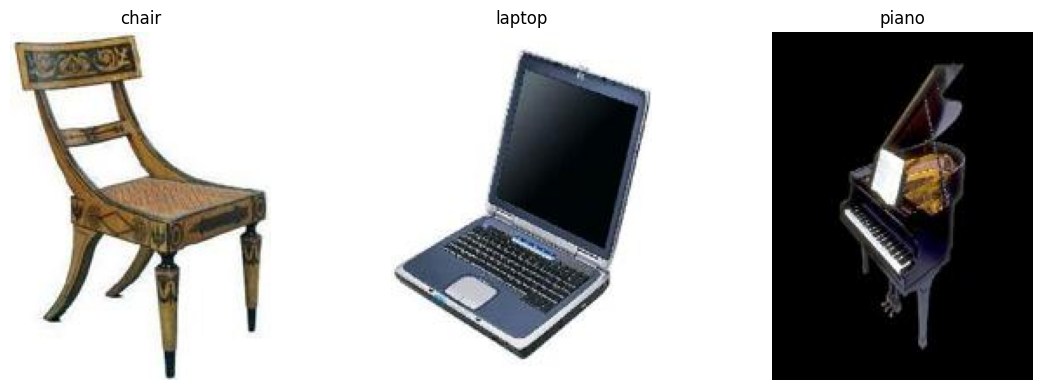

In [4]:
image_files = []
target = []

for label, name in enumerate(dirNames):
    files = sorted(glob.glob(f"../../keras/Data/exColor/{name}/*.jpg"))
    print(name, len(files))
    for file in files:
        image_files.append(file)
        target.append(label)

images = np.zeros((len(image_files), img_height_size, img_width_size, img_color), dtype=np.int32)

for i, file in enumerate(image_files):
    img = Image.open(file).resize((img_width_size, img_height_size))
    images[i] = np.array(img, dtype=np.int32)

start_idx = 0
plt.figure(figsize=(12, 4))

for i, name in enumerate(dirNames):
    plt.subplot(1, len(dirNames), i + 1)
    plt.imshow(images[start_idx].astype(np.uint8))
    plt.title(name)
    plt.axis('off')
    file_count = len(sorted(glob.glob(f"../../keras/Data/exColor/{name}/*.jpg")))
    start_idx += file_count

plt.tight_layout()
plt.show()


In [5]:
train_input = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
train_target = torch.tensor(target, dtype=torch.long)

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42, stratify=train_target
)

batch_size = 8
train_dataset = TensorDataset(train_input, train_target)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_input, val_target)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [6]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 50 * 37, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [7]:
device=torch.device("mps" if torch.backends.mps.is_available() else 'cpu')
print(device)
# model.to(device)#summary

mps


In [8]:
#모델, 손실함수, 옵티마이저 초기화
#모델 인스턴스
model=CNNModel().to(device)

#손실함수와 옵티마이저
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters())

In [9]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)


In [10]:
#평가함수
def evaluate(model, val_loader,criterion,device):
    model.eval()#eval:epochX
    total_loss=0#전체 손실 합계
    correct=0#정확하게 예측한 샘플수
    total=0#전체 샘플수
    with torch.no_grad():#평가는 가중치 바꾸면 안됌(자동미분)
        #with file close 안해도됨
        for inputs, targets in val_loader:
            inputs,targets= inputs.to(device),targets.to(device)
            outputs=model(inputs)
            loss=criterion(outputs,targets)
            total_loss+=loss.item()
            _, predicted= outputs.max(1)#선형회귀
            total+=targets.size(0)
            correct+=predicted.eq(targets).sum().item()

    return total_loss/len(val_loader),correct/total #평균손실, 정확도        


In [11]:
model.to(device)#summary

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=118400, out_features=128, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

In [12]:
#훈련하기#reshape=>unsqueeze
#데이터 담아서 시각화
num_epochs=50
train_loss_scores=[]
val_loss_scores=[]
val_accuracy_scores=[]

best_val_loss = float('inf')
patience = 5  # 5번까지 기다림
counter = 0

for epoch in range(num_epochs):
    train_loss = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

    train_loss_scores.append(train_loss)
    val_loss_scores.append(val_loss)
    val_accuracy_scores.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss:{train_loss:.4f}, val_loss:{val_loss:.4f}, val accuracy:{val_accuracy:.4f}")

    # Early Stopping 핵심
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")  # 최고 모델 저장
    else:
        counter += 1
        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early Stopping 발생!")
            break

Epoch [1/50], Loss:2.3585, val_loss:1.0425, val accuracy:0.6098
Epoch [2/50], Loss:0.9075, val_loss:0.8637, val accuracy:0.5122
Epoch [3/50], Loss:0.6785, val_loss:0.5538, val accuracy:0.6829
Epoch [4/50], Loss:0.4057, val_loss:0.7218, val accuracy:0.6829
EarlyStopping counter: 1/5
Epoch [5/50], Loss:0.2734, val_loss:0.4096, val accuracy:0.8293
Epoch [6/50], Loss:0.1689, val_loss:0.3719, val accuracy:0.8049
Epoch [7/50], Loss:0.0940, val_loss:0.3418, val accuracy:0.8780
Epoch [8/50], Loss:0.0696, val_loss:0.4025, val accuracy:0.7317
EarlyStopping counter: 1/5
Epoch [9/50], Loss:0.0563, val_loss:0.4576, val accuracy:0.8537
EarlyStopping counter: 2/5
Epoch [10/50], Loss:0.0455, val_loss:0.3106, val accuracy:0.8537
Epoch [11/50], Loss:0.0251, val_loss:0.4785, val accuracy:0.8537
EarlyStopping counter: 1/5
Epoch [12/50], Loss:0.0102, val_loss:0.3475, val accuracy:0.8780
EarlyStopping counter: 2/5
Epoch [13/50], Loss:0.0060, val_loss:0.3603, val accuracy:0.9024
EarlyStopping counter: 3/5
Ep

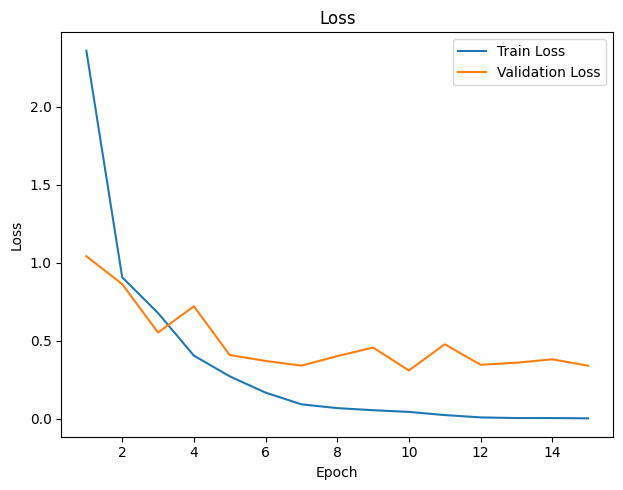

In [13]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_scores) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_scores, label='Train Loss')
plt.plot(epochs, val_loss_scores, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(epochs, val_accuracy_scores, label='Validation Accuracy', color='orange')
# plt.title('Validation Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()

plt.tight_layout()
plt.show()


In [14]:
train_loss, train_accuracy = evaluate(model, train_loader, criterion, device)
val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

modelResult = [train_accuracy, val_accuracy]
modelResult

#전체 모델 저장
torch.save(model,"../../keras/Data/ccn_chair.pth")

#전체 모델 불러오기
model1=torch.load("../../keras/Data/ccn_chair.pth",weights_only=False)

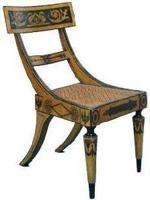

In [15]:
from PIL import Image
import numpy as np

# 첫 번째 chair 이미지 사용
abc=images[0].astype(np.uint8)
abc.shape

#Image 만들기
image=Image.fromarray(abc)
image

#image저장
image.save("../../keras/Data/chair_00.png")

#image불러와서 예측
img=Image.open("../../keras/Data/chair_00.png")
img


In [16]:
#image를 numpyarray
img=np.array(img)
img=torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
img.shape

img.shape

classes = ['chair', 'laptop', 'piano']

def predictOne(model, image, device, classes):
    model.eval()
    with torch.no_grad():
        image = image.to(device)
        outputs = model(image.unsqueeze(0))
        _, predicted = torch.max(outputs, 1)
        predicted_classes = classes[predicted.item()]
    return predicted_classes

chair_files = sorted(glob.glob("../../keras/Data/exColor/chair/*.jpg"))

img = np.array(Image.open(chair_files[0]), dtype=np.int32)
img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

predictOne(model, img, device, classes)

'chair'